In [1]:
from google.colab import files

uploaded = files.upload()

Saving Ecommerce_Orders_Missing.csv to Ecommerce_Orders_Missing.csv


In [2]:
import pandas as pd

df = pd.read_csv("Ecommerce_Orders_Missing.csv")

df.head()

,Order_ID,Customer_Age,Order_Amount,Shipping_Cost,Delivery_Days,Items_Count,Customer_Rating,Payment_Method,City
0,ORD1001,56.0,300.45,49.51,5.0,1.0,2.1,Apple Pay,Jeddah
1,ORD1002,46.0,274.86,41.46,9.0,6.0,1.8,Card,Khobar
2,ORD1003,32.0,NaN,67.81,4.0,7.0,4.5,Cash,Jeddah
3,ORD1004,60.0,221.20,36.13,10.0,7.0,4.0,Card,Riyadh
4,ORD1005,NaN,411.83,18.12,5.0,1.0,1.2,Card,Dammam


In [3]:
df.shape

(120, 9)

In [4]:
df.dtypes

,0
Order_ID,object
Customer_Age,float64
Order_Amount,float64
Shipping_Cost,float64
Delivery_Days,float64
Items_Count,float64
Customer_Rating,float64
Payment_Method,object
City,object


In [5]:
df.isnull().sum()

,0
Order_ID,0
Customer_Age,4
Order_Amount,5
Shipping_Cost,4
Delivery_Days,3
Items_Count,0
Customer_Rating,5
Payment_Method,2
City,2


In [6]:
df.describe()

,Customer_Age,Order_Amount,Shipping_Cost,Delivery_Days,Items_Count,Customer_Rating
count,116.000000,115.000000,116.000000,117.000000,120.000000,115.000000
mean,40.793103,364.584348,40.033793,6.008547,4.333333,2.987826
std,14.028863,264.341054,24.434685,4.050321,2.327524,1.054327
min,18.000000,40.000000,11.060000,1.000000,1.000000,1.000000
25%,28.000000,258.995000,29.425000,3.000000,2.000000,2.250000
50%,41.000000,328.460000,36.320000,5.000000,5.000000,3.100000
75%,53.000000,409.675000,46.025000,9.000000,6.000000,3.800000
max,65.000000,2200.000000,220.000000,30.000000,8.000000,4.900000


In [8]:
df_clean = df.copy()

In [11]:
df_clean['Customer_Age'] = df_clean['Customer_Age'].fillna(df_clean['Customer_Age'].median())
df_clean['Order_Amount'] = df_clean['Order_Amount'].fillna(df_clean['Order_Amount'].median())
df_clean['Shipping_Cost'] = df_clean['Shipping_Cost'].fillna(df_clean['Shipping_Cost'].median())
df_clean['Delivery_Days'] = df_clean['Delivery_Days'].fillna(df_clean['Delivery_Days'].median())
df_clean['Customer_Rating'] = df_clean['Customer_Rating'].fillna(df_clean['Customer_Rating'].median())

In [12]:
df_clean.isnull().sum()

,0
Order_ID,0
Customer_Age,0
Order_Amount,0
Shipping_Cost,0
Delivery_Days,0
Items_Count,0
Customer_Rating,0
Payment_Method,2
City,2


In [13]:
df_clean['Payment_Method'] = df_clean['Payment_Method'].fillna(df_clean['Payment_Method'].mode()[0])

df_clean['City'] = df_clean['City'].fillna(df_clean['City'].mode()[0])

In [14]:
df_clean.isnull().sum()

,0
Order_ID,0
Customer_Age,0
Order_Amount,0
Shipping_Cost,0
Delivery_Days,0
Items_Count,0
Customer_Rating,0
Payment_Method,0
City,0


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

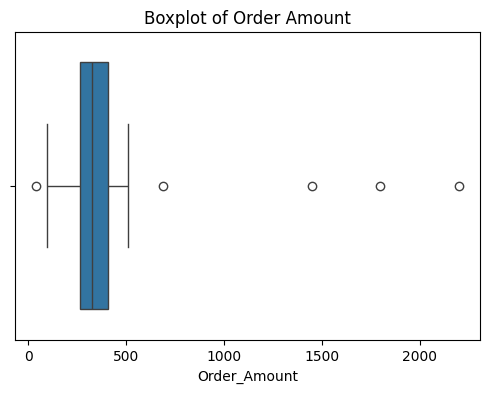

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['Order_Amount'])
plt.title("Boxplot of Order Amount")
plt.show()

In [18]:
Q1 = df_clean['Order_Amount'].quantile(0.25)
Q3 = df_clean['Order_Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 264.59250000000003
Q3: 405.6675
IQR: 141.075
Lower Bound: 52.98000000000005
Upper Bound: 617.28


In [19]:
outliers = df_clean[
(df_clean['Order_Amount'] < lower_bound) |
(df_clean['Order_Amount'] > upper_bound)
]

outliers

,Order_ID,Customer_Age,Order_Amount,Shipping_Cost,Delivery_Days,Items_Count,Customer_Rating,Payment_Method,City
7,ORD1008,36.0,1450.00,46.73,3.0,6.0,3.0,Cash,Riyadh
12,ORD1013,53.0,690.95,29.57,1.0,3.0,4.9,Cash,Dammam
38,ORD1039,24.0,40.00,50.97,5.0,3.0,4.1,Cash,Khobar
48,ORD1049,19.0,1800.00,13.54,7.0,8.0,3.3,Apple Pay,Riyadh
97,ORD1098,26.0,2200.00,45.92,7.0,6.0,1.4,Card,Jeddah


In [20]:
df_no_outliers = df_clean[
(df_clean['Order_Amount'] >= lower_bound) &
(df_clean['Order_Amount'] <= upper_bound)
]

print("Before removing outliers:", df_clean.shape)
print("After removing outliers:", df_no_outliers.shape)

Before removing outliers: (120, 9)
After removing outliers: (115, 9)


In [21]:
features = [
'Customer_Age',
'Order_Amount',
'Shipping_Cost',
'Delivery_Days',
'Items_Count',
'Customer_Rating'
]

In [22]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df_no_outliers[features].copy()

df_minmax[features] = minmax_scaler.fit_transform(df_minmax[features])

df_minmax.head()

,Customer_Age,Order_Amount,Shipping_Cost,Delivery_Days,Items_Count,Customer_Rating
0,0.808511,0.494661,0.184024,0.137931,0.000000,0.282051
1,0.595745,0.432274,0.145496,0.275862,0.714286,0.205128
2,0.297872,0.562948,0.271609,0.103448,0.857143,0.897436
3,0.893617,0.301453,0.119987,0.310345,0.857143,0.769231
4,0.489362,0.766200,0.033790,0.137931,0.000000,0.051282


In [23]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

df_zscore = df_no_outliers[features].copy()

df_zscore[features] = standard_scaler.fit_transform(df_zscore[features])

df_zscore.head()

,Customer_Age,Order_Amount,Shipping_Cost,Delivery_Days,Items_Count,Customer_Rating
0,1.083256,-0.268024,0.391052,-0.258853,-1.417142,-0.861574
1,0.351326,-0.546067,0.059286,0.733416,0.732875,-1.156166
2,-0.673375,0.036314,1.145253,-0.506920,1.162879,1.495160
3,1.376028,-1.129100,-0.160380,0.981484,1.162879,1.004174
4,-0.014639,0.942156,-0.902629,-0.258853,-1.417142,-1.745349


In [24]:
from sklearn.decomposition import PCA

pca = PCA()

principal_components = pca.fit_transform(df_zscore)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.22402799 0.20829694 0.18315373 0.14372206 0.12997072 0.11082856]


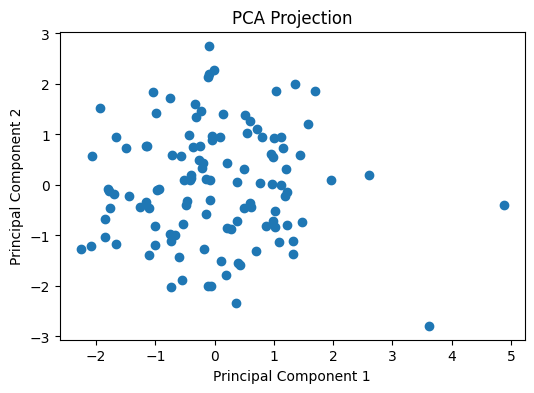

In [25]:
pca_2 = PCA(n_components=2)

principal_components_2 = pca_2.fit_transform(df_zscore)

plt.figure(figsize=(6,4))

plt.scatter(
principal_components_2[:, 0],
principal_components_2[:, 1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")

plt.show()

In [26]:
print("Explained Variance Ratio for PC1 and PC2:")
print(pca_2.explained_variance_ratio_)

print("Total Explained Variance:")
print(pca_2.explained_variance_ratio_.sum())

Explained Variance Ratio for PC1 and PC2:
[0.22402799 0.20829694]
Total Explained Variance:
0.4323249245800731


The dataset was assessed for data quality issues including missing values and outliers. Missing numerical values were handled using median imputation, while categorical missing values were handled using the mode. Outliers in Order Amount were detected and removed using the IQR method. Min-Max normalization and Z-score standardization were applied to numerical features. Finally, PCA was used to reduce dimensionality and analyze the explained variance of the principal components.